In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4935
Epoca [10/100] | Loss: 0.1916
Epoca [20/100] | Loss: 0.0550
Epoca [30/100] | Loss: 0.0216
Epoca [40/100] | Loss: 0.0099
Epoca [50/100] | Loss: 0.0060
Epoca [60/100] | Loss: 0.0045
Epoca [70/100] | Loss: 0.0036
Epoca [80/100] | Loss: 0.0033
Epoca [90/100] | Loss: 0.0030
Epoca [100/100] | Loss: 0.0028

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0037
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

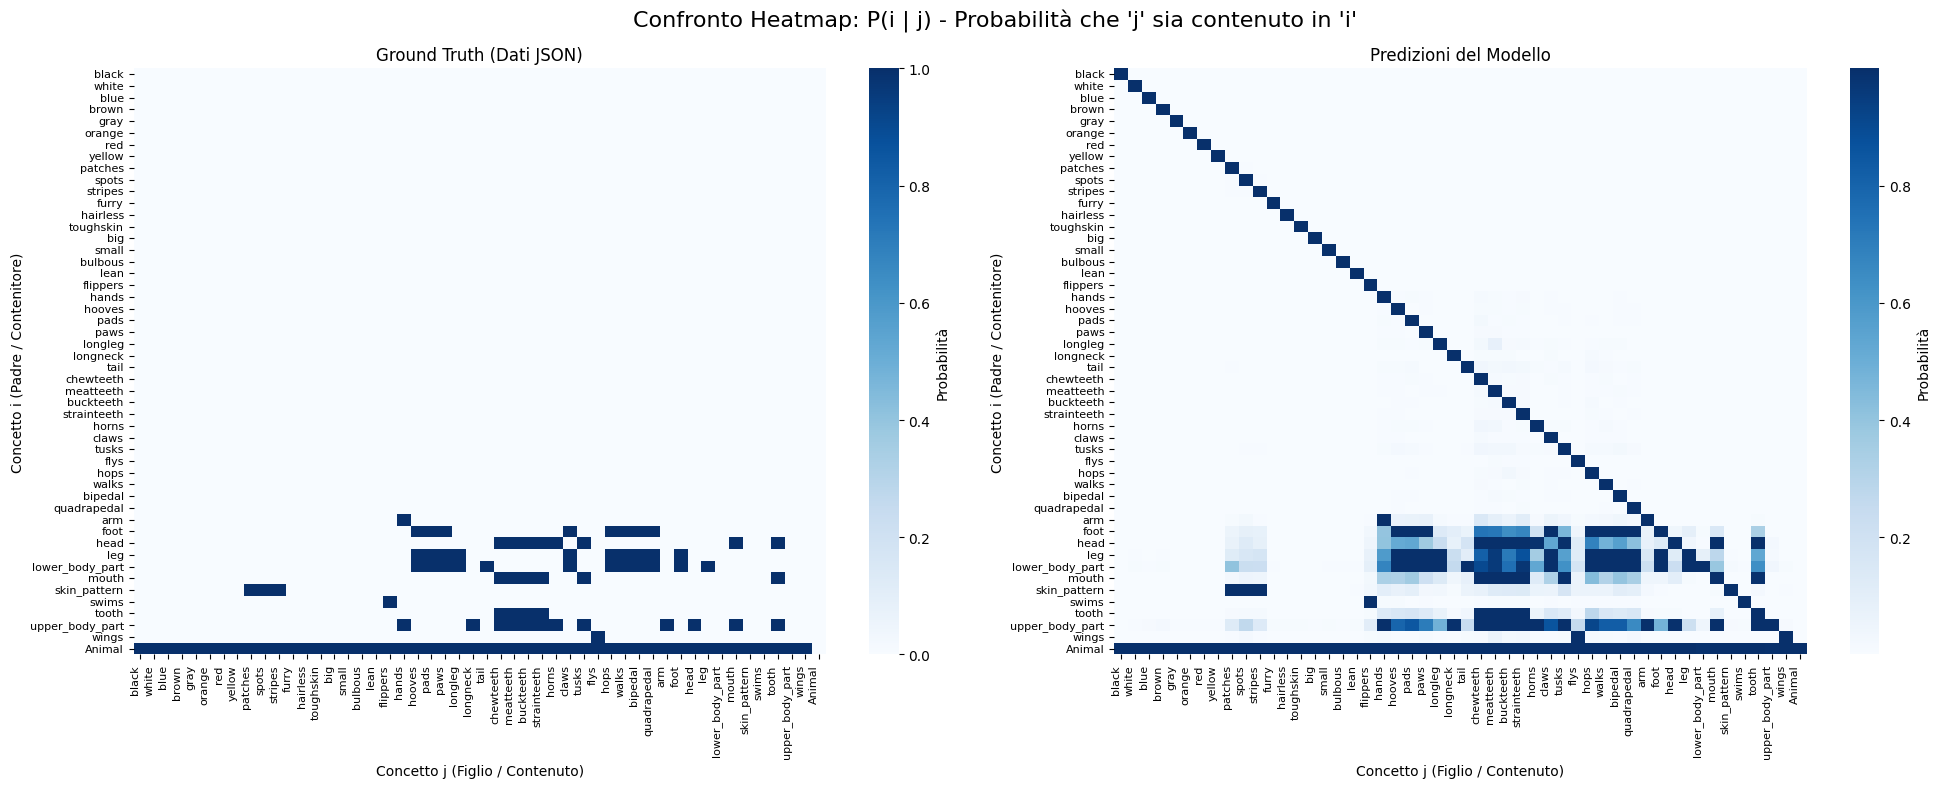

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

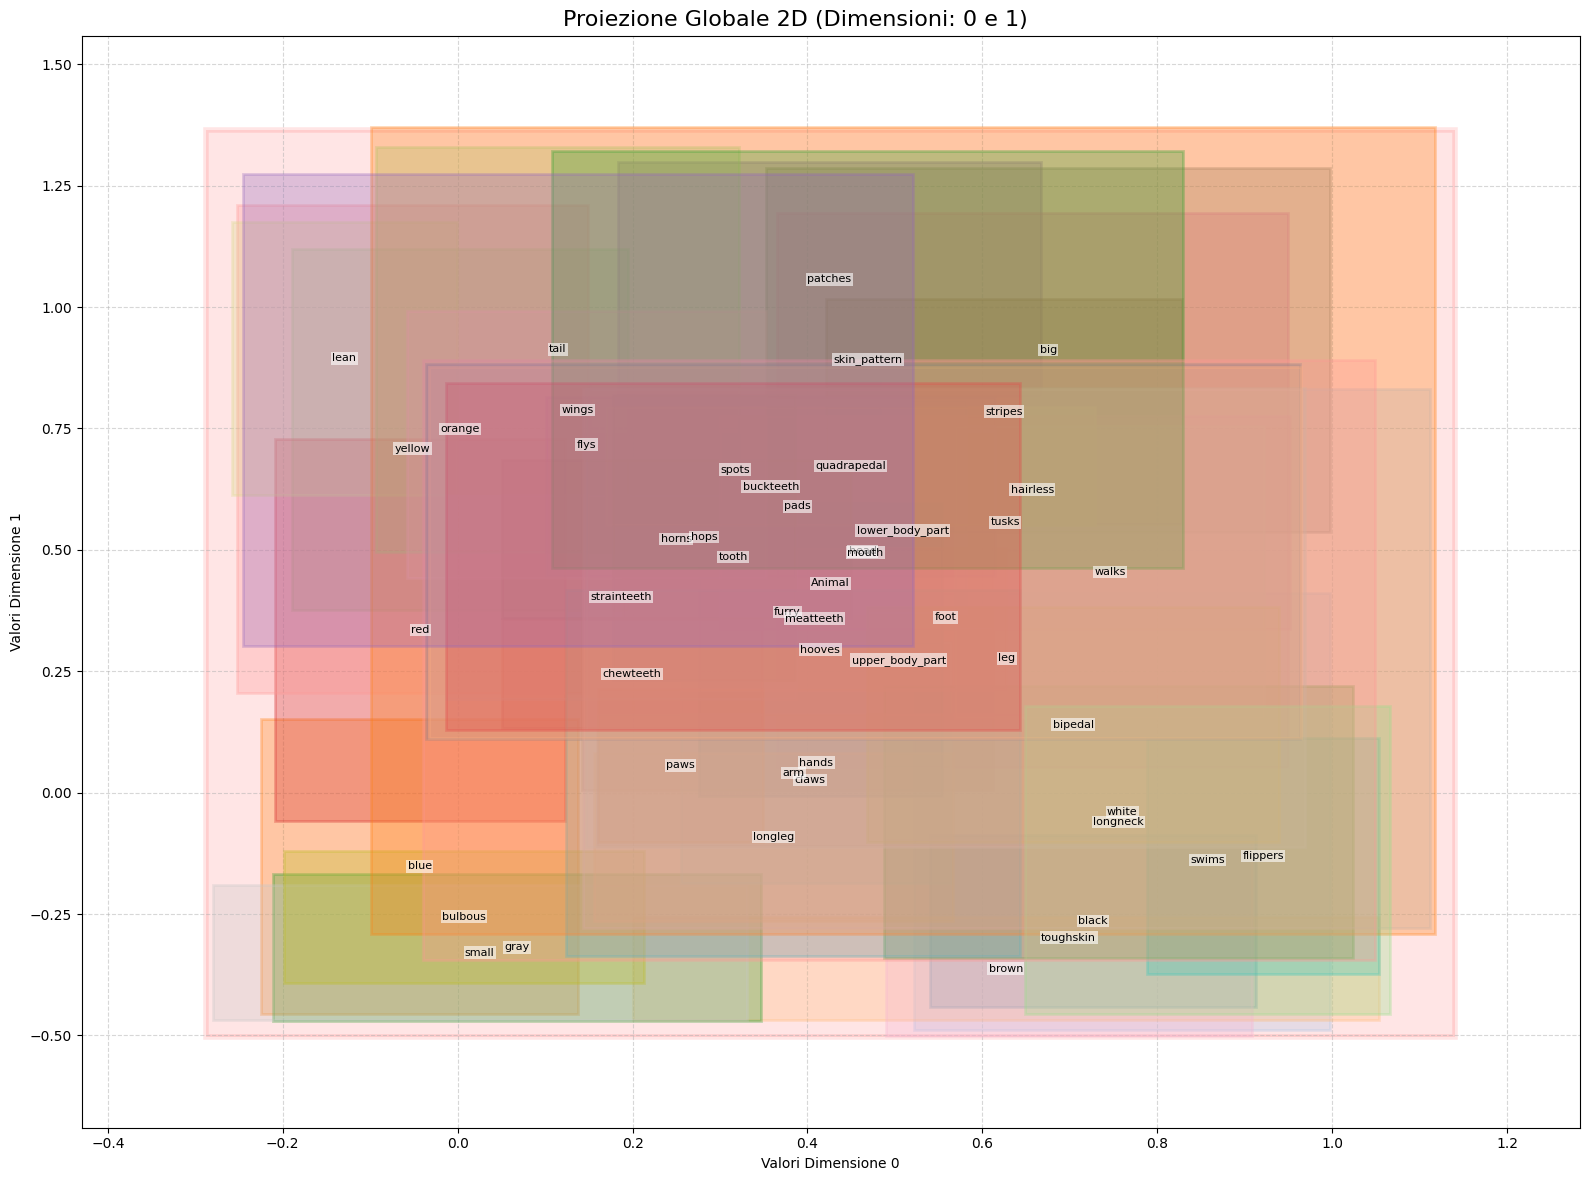

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

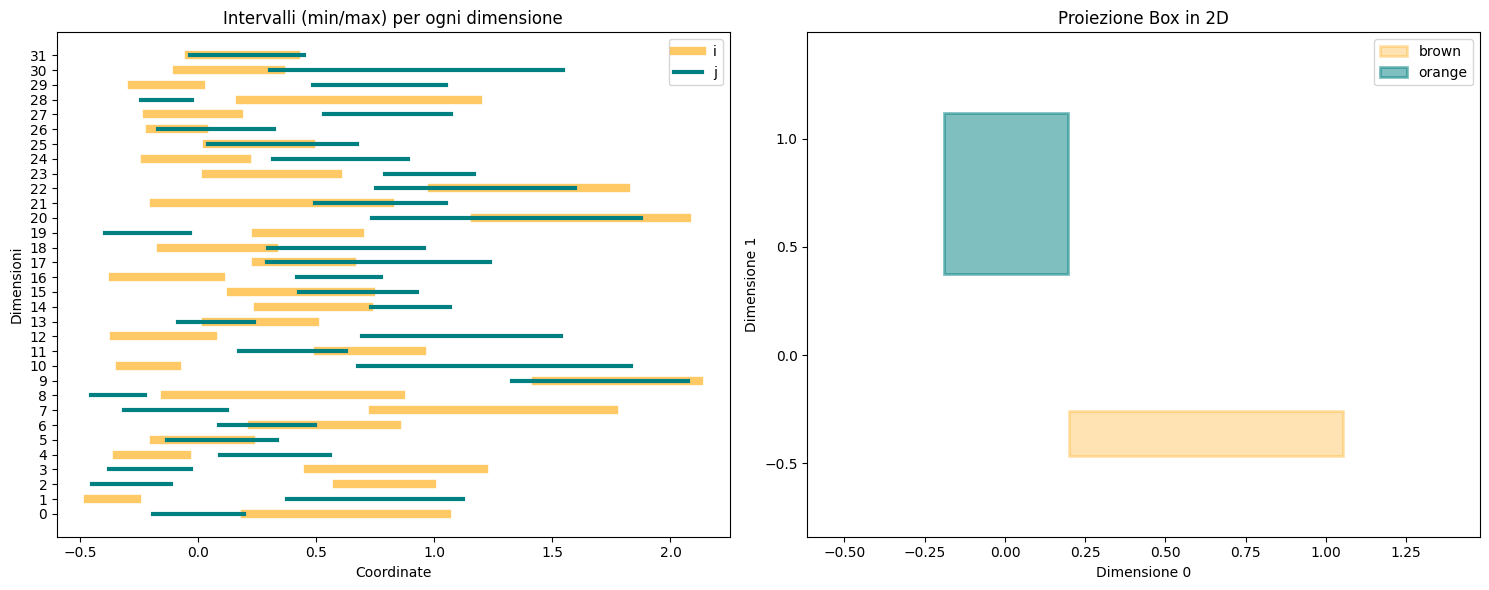

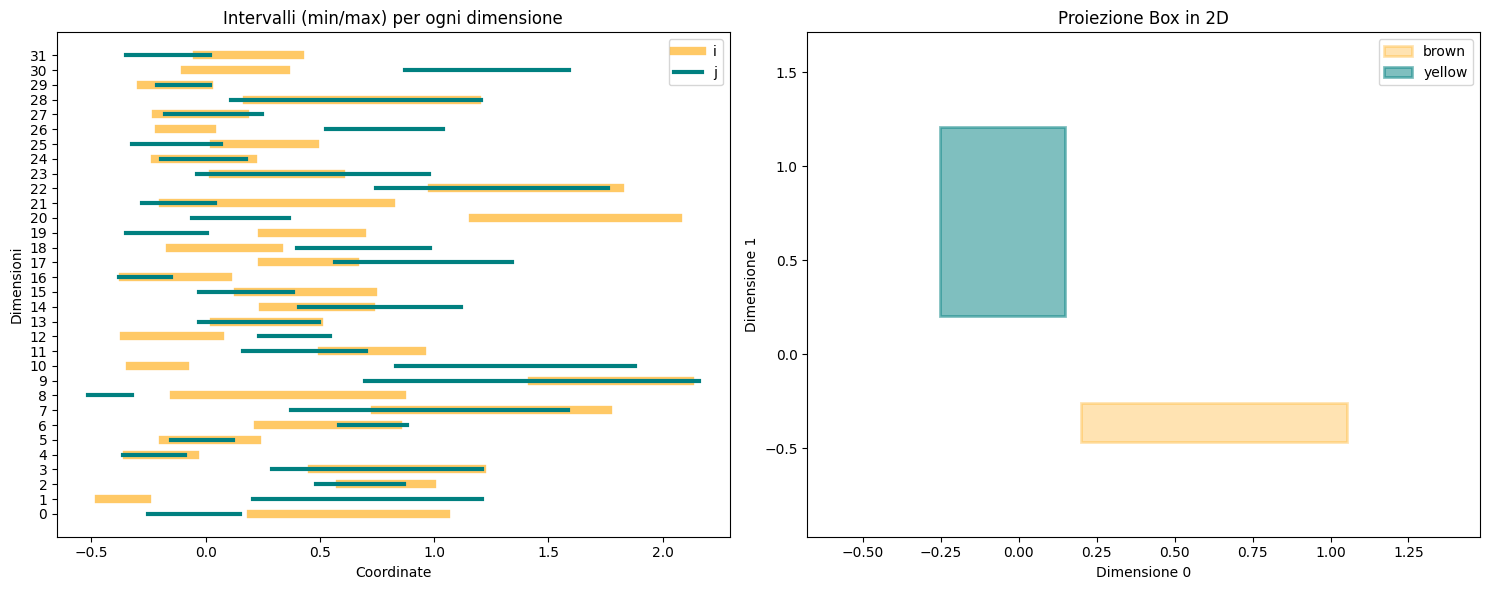

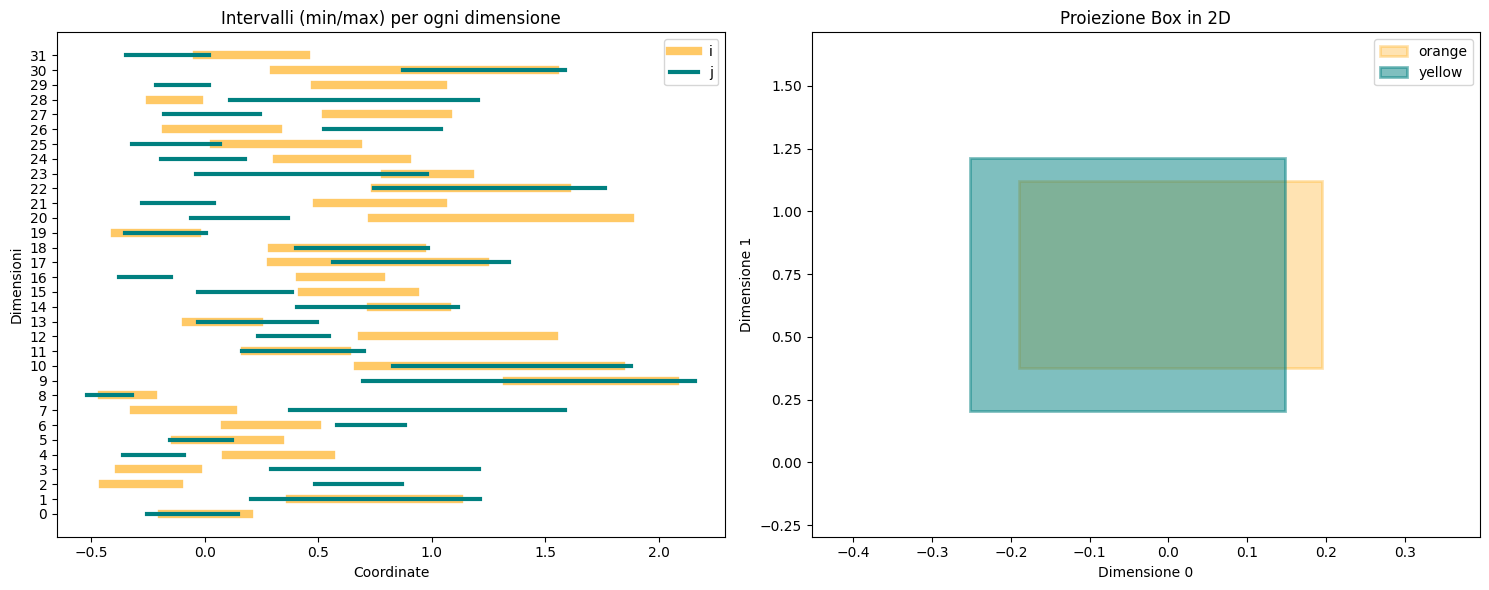

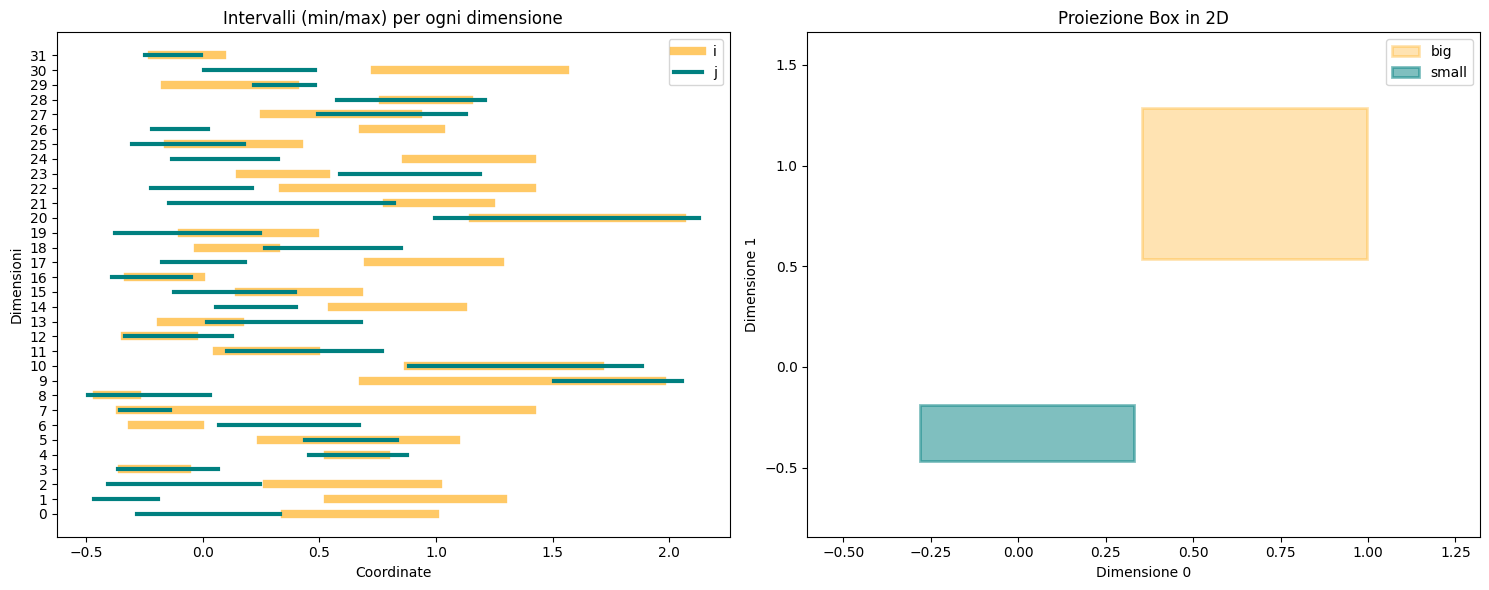

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [14]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [15]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [16]:
box_dict = get_box_dict(box_model, id2concept)

In [17]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [18]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import sequential_training
import matplotlib.pyplot as plt
from src.CHM.test import test_sequential_cbm
from src.utils.plot import plot_history, plot_test_results

### CBM with boxes

#### Train

In [19]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5543 | Acc: 95.9613 || Val Loss: 2.5829 | Val Acc: 97.0051
Loss: 2.2493 | Acc: 97.4247 || Val Loss: 2.3362 | Val Acc: 97.2521
Loss: 1.9576 | Acc: 97.7497 || Val Loss: 2.2281 | Val Acc: 97.3646
Loss: 1.7857 | Acc: 97.9443 || Val Loss: 2.1806 | Val Acc: 97.4026
Loss: 1.6557 | Acc: 98.0841 || Val Loss: 2.1464 | Val Acc: 97.5082
Loss: 1.5649 | Acc: 98.1854 || Val Loss: 2.1136 | Val Acc: 97.5280
Loss: 1.4945 | Acc: 98.2703 || Val Loss: 2.1307 | Val Acc: 97.5248
Loss: 1.4331 | Acc: 98.3388 || Val Loss: 2.1162 | Val Acc: 97.5773
Loss: 1.3849 | Acc: 98.3909 || Val Loss: 2.1416 | Val Acc: 97.5564
Loss: 1.3360 | Acc: 98.4594 || Val Loss: 2.1903 | Val Acc: 97.5076
Loss: 1.3019 | Acc: 98.4945 || Val Loss: 2.2129 | Val Acc: 97.5226
Loss: 1.2704 | Acc: 98.5401 || Val Loss: 2.2001 | Val Acc: 97.5425
Loss: 1.2349 | Acc: 98.5669 || Val Loss: 2.2167 | Val Acc: 97.5237
Loss: 1.2127 | Acc: 98.5972 || Val Loss: 2.2998 | Val Ac

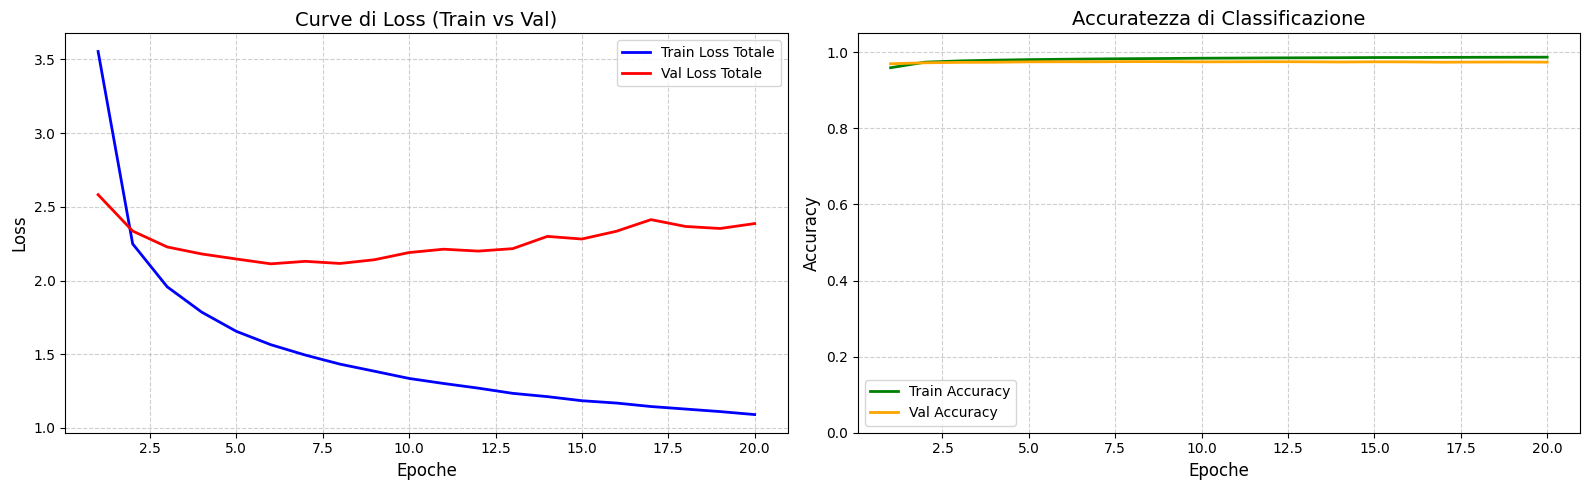

In [20]:
plot_history(b_conc_history)

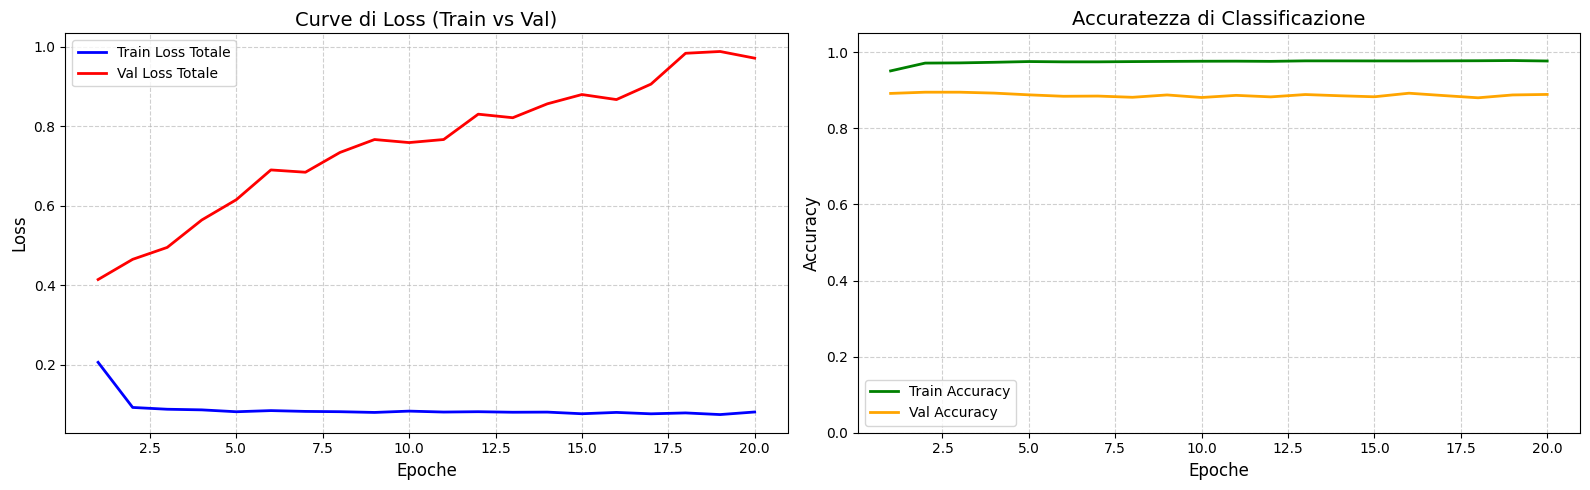

In [21]:
plot_history(b_cls_history)

#### Test

In [22]:
accuracy, preds, labels = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 89.30% (6666/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       209
           1       0.86      0.92      0.89       170
           2       0.65      0.74      0.69        58
           3       0.77      0.71      0.74        38
           4       0.96      0.98      0.97       110
           5       0.95      0.89      0.92       149
           6       0.93      0.91      0.92       329
           7       0.88      0.86      0.87       207
           8       0.50      0.40      0.44        35
           9       0.72      0.85      0.78       100

   micro avg       0.86      0.88      0.87      1405
   macro avg       0.81      0.82      0.81      1405
weighted avg       0.86      0.88      0.87      1405



In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

In [23]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
    logical_smoothing=True,
    alpha=0.3
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5341 | Acc: 95.9808 || Val Loss: 2.5676 | Val Acc: 97.0287
Loss: 2.2458 | Acc: 97.4384 || Val Loss: 2.2970 | Val Acc: 97.3190
Loss: 1.9534 | Acc: 97.7538 || Val Loss: 2.2226 | Val Acc: 97.4026
Loss: 1.7806 | Acc: 97.9514 || Val Loss: 2.1736 | Val Acc: 97.4610
Loss: 1.6609 | Acc: 98.0681 || Val Loss: 2.1764 | Val Acc: 97.4712
Loss: 1.5704 | Acc: 98.1873 || Val Loss: 2.0976 | Val Acc: 97.5714
Loss: 1.4922 | Acc: 98.2823 || Val Loss: 2.1568 | Val Acc: 97.5066
Loss: 1.4341 | Acc: 98.3454 || Val Loss: 2.1513 | Val Acc: 97.5312
Loss: 1.3788 | Acc: 98.4030 || Val Loss: 2.1646 | Val Acc: 97.5307
Loss: 1.3390 | Acc: 98.4559 || Val Loss: 2.2012 | Val Acc: 97.4750
Loss: 1.2990 | Acc: 98.4938 || Val Loss: 2.1580 | Val Acc: 97.5585
Loss: 1.2684 | Acc: 98.5285 || Val Loss: 2.2091 | Val Acc: 97.4942
Loss: 1.2368 | Acc: 98.5772 || Val Loss: 2.1910 | Val Acc: 97.5355
Loss: 1.2080 | Acc: 98.6102 || Val Loss: 2.2465 | Val Ac

In [24]:
accuracy, preds, labels = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
    logical_smoothing=True,
    alpha=0.3
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 89.31% (6667/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.95      0.85      0.89       209
           1       0.96      0.77      0.86       170
           2       0.77      0.88      0.82        58
           3       0.79      0.68      0.73        38
           4       0.96      0.97      0.97       110
           5       0.97      0.87      0.92       149
           6       0.97      0.92      0.95       329
           7       0.76      0.92      0.83       207
           8       0.34      0.57      0.43        35
           9       0.66      0.92      0.77       100

   micro avg       0.86      0.87      0.87      1405
   macro avg       0.81      0.84      0.82      1405
weighted avg       0.88      0.87      0.87      1405



### CBM with cond prob distrib

#### Train

In [27]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_optimizer = torch.optim.Adam(cp_cls.parameters(), lr=0.001)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_concept_optimizer = torch.optim.Adam(cp_concept_predictor.parameters(), lr=0.001)
cp_concept_criterion = nn.BCEWithLogitsLoss()

cp_conc_history, cp_cls_history = sequential_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,  
    cp_concept_optimizer,
    cp_criterion,
    cp_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5650 | Acc: 95.9246 || Val Loss: 2.6222 | Val Acc: 96.9660
Loss: 2.2481 | Acc: 97.4379 || Val Loss: 2.3168 | Val Acc: 97.2489
Loss: 1.9573 | Acc: 97.7447 || Val Loss: 2.2129 | Val Acc: 97.4316
Loss: 1.7781 | Acc: 97.9458 || Val Loss: 2.1675 | Val Acc: 97.4578
Loss: 1.6617 | Acc: 98.0800 || Val Loss: 2.1256 | Val Acc: 97.5151
Loss: 1.5681 | Acc: 98.1810 || Val Loss: 2.2303 | Val Acc: 97.4182
Loss: 1.5010 | Acc: 98.2559 || Val Loss: 2.1596 | Val Acc: 97.4717
Loss: 1.4303 | Acc: 98.3536 || Val Loss: 2.2128 | Val Acc: 97.4707
Loss: 1.3775 | Acc: 98.4098 || Val Loss: 2.1624 | Val Acc: 97.5628
Loss: 1.3353 | Acc: 98.4556 || Val Loss: 2.1994 | Val Acc: 97.5001
Loss: 1.3021 | Acc: 98.5002 || Val Loss: 2.1989 | Val Acc: 97.5457
Loss: 1.2642 | Acc: 98.5320 || Val Loss: 2.1951 | Val Acc: 97.5462
Loss: 1.2403 | Acc: 98.5644 || Val Loss: 2.2785 | Val Acc: 97.4455
Loss: 1.2168 | Acc: 98.5985 || Val Loss: 2.2221 | Val Ac

In [ ]:
plot_history(cp_conc_history)

In [ ]:
plot_history(cp_cls_history)

#### Test

In [28]:
cp_accuracy, cp_preds, cp_labels = test_sequential_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 89.79% (6703/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       209
           1       0.87      0.92      0.90       170
           2       0.81      0.81      0.81        58
           3       0.71      0.71      0.71        38
           4       0.92      0.99      0.96       110
           5       0.96      0.95      0.96       149
           6       0.92      0.95      0.93       329
           7       0.89      0.86      0.87       207
           8       0.36      0.29      0.32        35
           9       0.75      0.92      0.83       100

   micro avg       0.87      0.90      0.88      1405
   macro avg       0.80      0.83      0.82      1405
weighted avg       0.86      0.90      0.88      1405



In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

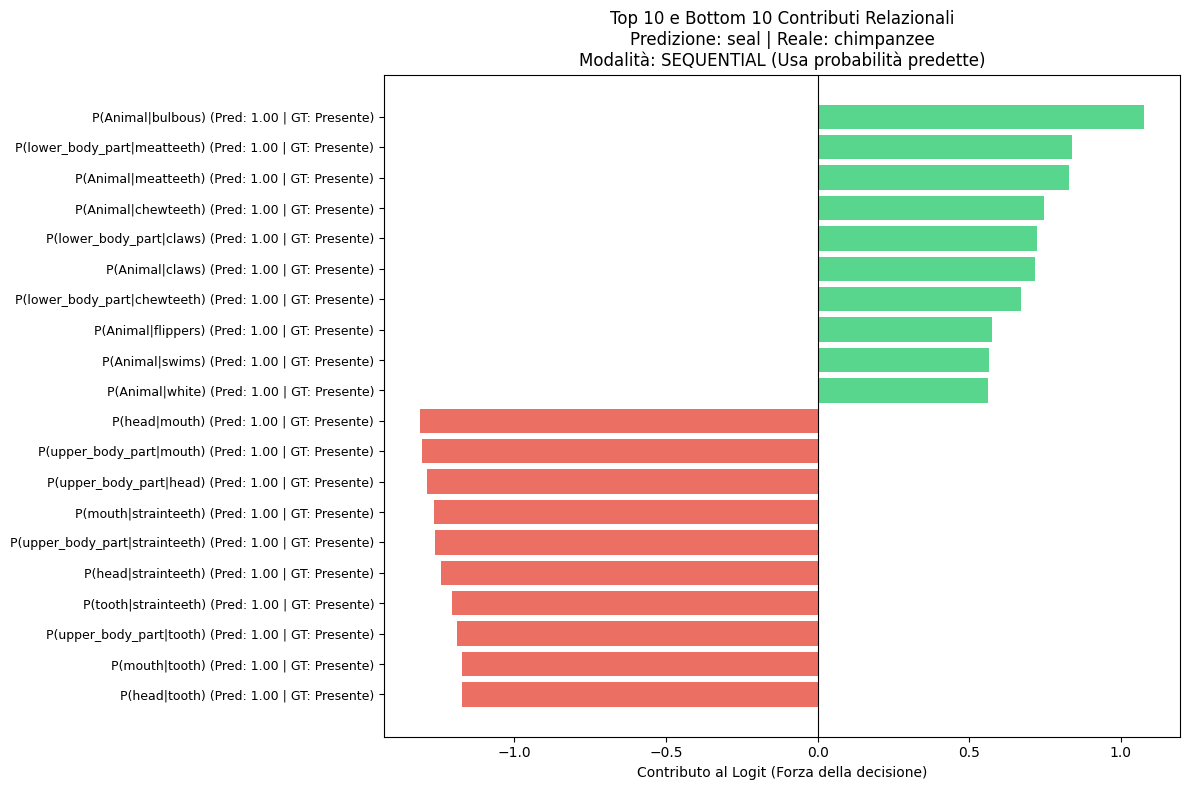

False

In [29]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

In [30]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_optimizer = torch.optim.Adam(cp_cls.parameters(), lr=0.001)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_concept_optimizer = torch.optim.Adam(cp_concept_predictor.parameters(), lr=0.001)
cp_concept_criterion = nn.BCEWithLogitsLoss()
alpha = 0.2

cp_conc_history, cp_cls_history = sequential_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,  
    cp_concept_optimizer,
    cp_criterion,
    cp_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
    logical_smoothing=True,
    alpha=alpha
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5409 | Acc: 95.9699 || Val Loss: 2.6221 | Val Acc: 96.9751
Loss: 2.2477 | Acc: 97.4198 || Val Loss: 2.3235 | Val Acc: 97.2735
Loss: 1.9537 | Acc: 97.7485 || Val Loss: 2.1966 | Val Acc: 97.4369
Loss: 1.7818 | Acc: 97.9531 || Val Loss: 2.1542 | Val Acc: 97.4851
Loss: 1.6582 | Acc: 98.0861 || Val Loss: 2.1777 | Val Acc: 97.4626
Loss: 1.5686 | Acc: 98.1828 || Val Loss: 2.1515 | Val Acc: 97.4830
Loss: 1.4979 | Acc: 98.2585 || Val Loss: 2.1476 | Val Acc: 97.5414
Loss: 1.4351 | Acc: 98.3522 || Val Loss: 2.1478 | Val Acc: 97.4985
Loss: 1.3846 | Acc: 98.3975 || Val Loss: 2.1928 | Val Acc: 97.4760
Loss: 1.3381 | Acc: 98.4541 || Val Loss: 2.1760 | Val Acc: 97.5291
Loss: 1.3028 | Acc: 98.4953 || Val Loss: 2.2072 | Val Acc: 97.5210
Loss: 1.2645 | Acc: 98.5458 || Val Loss: 2.2530 | Val Acc: 97.4685
Loss: 1.2383 | Acc: 98.5653 || Val Loss: 2.2632 | Val Acc: 97.4653
Loss: 1.2121 | Acc: 98.6001 || Val Loss: 2.2767 | Val Ac

In [31]:
cp_accuracy, cp_preds, cp_labels = test_sequential_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
    logical_smoothing=True,
    alpha=alpha
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.09% (6725/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.79      0.93      0.86       209
           1       0.89      0.90      0.90       170
           2       0.81      0.79      0.80        58
           3       0.78      0.76      0.77        38
           4       0.96      0.96      0.96       110
           5       0.93      0.95      0.94       149
           6       0.92      0.94      0.93       329
           7       0.88      0.86      0.87       207
           8       0.00      0.00      0.00        35
           9       0.74      0.92      0.82       100

   micro avg       0.87      0.89      0.88      1405
   macro avg       0.77      0.80      0.79      1405
weighted avg       0.85      0.89      0.87      1405



In [32]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
    logical_smoothing=True,
    alpha=alpha
)

TypeError: matmul(): argument 'other' (position 2) must be Tensor, not NoneType

### CBM standard

In [ ]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_optimizer = torch.optim.Adam(c_cls.parameters(), lr=0.001)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_concept_optimizer = torch.optim.Adam(c_concept_predictor.parameters(), lr=0.001)
c_concept_criterion = nn.BCEWithLogitsLoss()

c_conc_history, c_cls_history = sequential_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,  
    c_concept_optimizer,
    c_criterion,
    c_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

In [ ]:
from src.CHM.train import plot_history
plot_history(c_conc_history)

In [ ]:
plot_history(c_cls_history)

In [ ]:
c_accuracy, c_preds, c_labels = test_sequential_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM ALL

#### Train

In [ ]:
info = "all"
bipolar = True
a_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
a_optimizer = torch.optim.Adam(a_cls.parameters(), lr=0.001)
a_criterion = nn.CrossEntropyLoss()

a_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
a_concept_optimizer = torch.optim.Adam(a_concept_predictor.parameters(), lr=0.001)
a_concept_criterion = nn.BCEWithLogitsLoss()

a_conc_history, a_cls_history = sequential_training(
    a_cls,
    a_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    a_optimizer,  
    a_concept_optimizer,
    a_criterion,
    a_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

#### Test

In [ ]:
a_accuracy, a_preds, a_labels = test_sequential_cbm(
    a_cls,
    a_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)